[2026-06-12 Fiddler](https://thefiddler.substack.com/p/can-you-catch-the-longest-wave)
====================

Fiddler
-------

Let the northwestern extreme be at $x_n = -\cos\theta$, $y_n = \sin\theta$, where
$0 \le \theta \le \pi/2$, so the southeastern extreme will be at $x_s = 1$, $y_s = 0$.

At 10:05, $x_m = \frac{1-\cos\theta}2$, $y_m = \frac{\sin\theta}2$ will be under the
wave.  At that moment, the line of the wave will be

In [1]:
theta = var('theta')
xn = -cos(theta)
yn = sin(theta)
xs = 1
ys = 0
xm = (xs+xn)/2
ym = (ys+yn)/2
x,y = var('x,y')
wave = y == ym + (x-xm)*tan(pi/2-theta)
show(wave)

y == 1/2*(2*x + cos(theta) - 1)*tan(1/2*pi - theta) + 1/2*sin(theta)

The 10:05 wave intersects the southwest corner of the island when $\theta = \theta_c \approx 1.231$.

When $\theta > \theta_c$, the 10:05 wave intersects the northern arc twice.  When $\theta < \theta_c$,
the 10:05 wave intersects both the southern beach and the northern arc.

In [2]:
thetac = find_root(wave.subs(x = -1, y = 0), 0, pi/2)
thetac

1.2309594173407747

And the maximum length is approximately 1.886 miles, which is when the 10:05 wave intersects
the southwest corner.

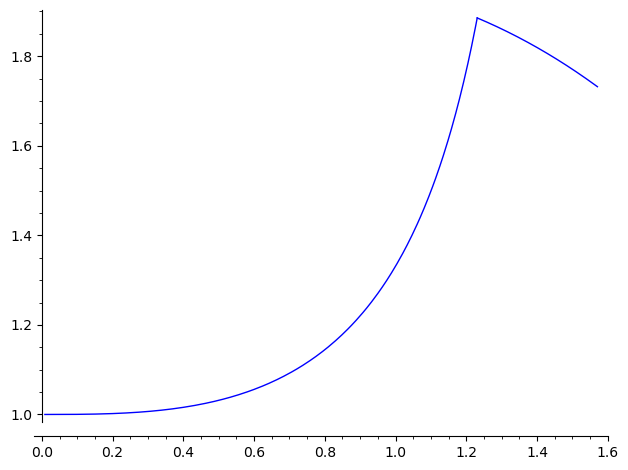

1.88561808316413

In [3]:
[x1, x2] = [sol.rhs() for sol in solve(wave.subs(y = sqrt(1-x^2))^2, x)]
y1, y2 = sqrt(1-x1^2), sqrt(1-x2^2)
x3 = solve(wave.subs(y = 0), x)[0].rhs()
y3 = 0
show(plot(sqrt((x2-x3)^2+(y2-y3)^2), theta, 0, thetac)
     + plot(sqrt((x2-x1)^2+(y2-y1)^2), theta, thetac, pi/2))
sqrt((x2-x3)^2+(y2-y3)^2).subs(theta=thetac)

Extra credit
------------
By symmetry, we only need to average over $0 \le \theta \le \pi/2$.

Evaluating the integral gives approximately 1.3044 miles.

In [4]:
l = (numerical_integral(sqrt((x2-x3)^2+(y2-y3)^2)/(pi/2), 0, thetac),
     numerical_integral(sqrt((x2-x1)^2+(y2-y1)^2)/(pi/2), thetac, pi/2))
l, l[0][0]+l[1][0]

(((0.9116048959213133, 1.0120847448128614e-14),
  (0.3928345591126548, 4.361339723953414e-15)),
 1.3044394550339682)